# Heart Disease Classification Using Machine Learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

Heart disease is one of the leading causes of death worldwide. Early detection of cardiovascular risk factors can help healthcare professionals take preventative action and improve patient outcomes.

The goal of this project is to develop a machine learning classification model that predicts whether a patient is likely to have heart disease based on various medical indicators such as age, cholesterol levels, blood pressure, and other health metrics.

This project demonstrates how data analysis and machine learning can be used to support healthcare decision-making.

### Objectives

- Perform exploratory data analysis (EDA) to understand patient health characteristics
- Identify key features associated with heart disease
- Build and evaluate classification models to predict heart disease
- Interpret model results and highlight important risk factors


## 1. Problem Definition 

In a statement, 
> Given clinical parameters about a patient, can we predict whether or not they have heart disease? 

## 2. Data 

The original data came from the Cleavland data from the UCI Machine Learning Repository.

There is also a version of it available on Kaggle https://www.kaggle.com/ronitf/heart-disease-uci?select=heart.csv

## 3. Evaluation 

Model performance was assessed using classification metrics such as:

- Accuracy
- Precision
- Recall
- Confusion Matrix

These metrics help evaluate how well the model predicts heart disease cases.

## 4. Features 

1. age - age in years 
2. sex - (1 = male; 0 = female) 
3. cp - chest pain type 
    * 0: Typical angina: chest pain related decrease blood supply to the heart
    * 1: Atypical angina: chest pain not related to heart
    * 2: Non-anginal pain: typically esophageal spasms (non heart related)
    * 3: Asymptomatic: chest pain not showing signs of disease
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital)
    * anything above 130-140 is typically cause for concern
5. chol - serum cholestoral in mg/dl 
    * serum = LDL + HDL + .2 * triglycerides
    * above 200 is cause for concern
6. fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false) 
    * '>126' mg/dL signals diabetes
7. restecg - resting electrocardiographic results
    * 0: Nothing to note
    * 1: ST-T Wave abnormality
        - can range from mild symptoms to severe problems
        - signals non-normal heart beat
    * 2: Possible or definite left ventricular hypertrophy
        - Enlarged heart's main pumping chamber
8. thalach - maximum heart rate achieved 
9. exang - exercise induced angina (1 = yes; 0 = no) 
10. oldpeak - ST depression induced by exercise relative to rest 
    * looks at stress of heart during excercise
    * unhealthy heart will stress more
11. slope - the slope of the peak exercise ST segment
    * 0: Upsloping: better heart rate with excercise (uncommon)
    * 1: Flatsloping: minimal change (typical healthy heart)
    * 2: Downslopins: signs of unhealthy heart
12. ca - number of major vessels (0-3) colored by flourosopy 
    * colored vessel means the doctor can see the blood passing through
    * the more blood movement the better (no clots)
13. thal - thalium stress result
    * 1,3: normal
    * 6: fixed defect: used to be defect but ok now
    * 7: reversable defect: no proper blood movement when excercising 
14. target - have disease or not (1=yes, 0=no) (= the predicted attribute)


### Key Insights

* Older patients are more likely to develop heart disease compared to younger individuals.

* Higher cholesterol levels show a strong association with heart disease risk.

* Certain chest pain categories are strongly associated with heart disease diagnosis.

* Lower maximum heart rate and increasing age are associated with a higher likelihood of heart disease but neither feature alone clearly separates the two groups. 


### Business / Healthcare Impact

Predictive models like this can support healthcare professionals by:

- Identifying high-risk patients earlier
- Supporting preventative healthcare decisions
- Improving clinical screening processes

While machine learning models cannot replace medical diagnosis, they can assist in risk assessment and decision support.


## Preparing the tools

We're going to use pandas, Matplotlib and NumPy for data analysis and manipulation 

In [1]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to appear inside the notebook
%matplotlib inline    


In [2]:
# Models from scikit-Learn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.metrics import precision_score, recall_score , f1_score
from sklearn.metrics import plot_roc_curve


## Load data 

In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
df.shape # (rows,columns)

(303, 14)

## Data Exploration (exploratory data analysis or EDA)

The goal here is to find out more about the data and become a subject matter expert on the dataset you're working with.

1. what question(s) are you trying to solve?
2. what kind of data do we have and how do we treat different types?
3. what's missing from the data and how do you deal with it?
4. where are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?


In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [8]:
df['target'].value_counts() 

1    165
0    138
Name: target, dtype: int64

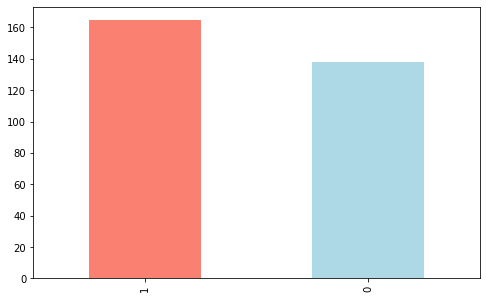

In [9]:
plt.figure(figsize=(8,5))

df['target'].value_counts().plot(kind='bar', color = ['salmon','lightblue']);

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
# Are there any missing values?
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

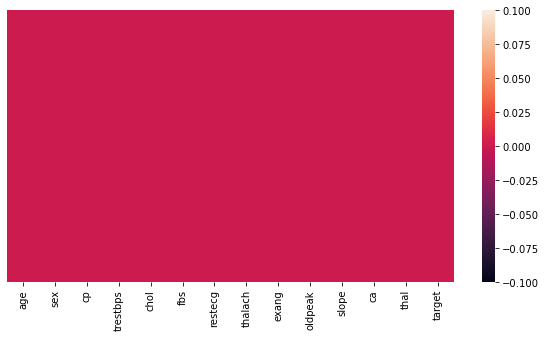

In [12]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),xticklabels=True,yticklabels=False);

In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to Sex 

In [14]:
df.sex.value_counts()

1    207
0     96
Name: sex, dtype: int64

In [15]:
# compare target column with sex column 
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


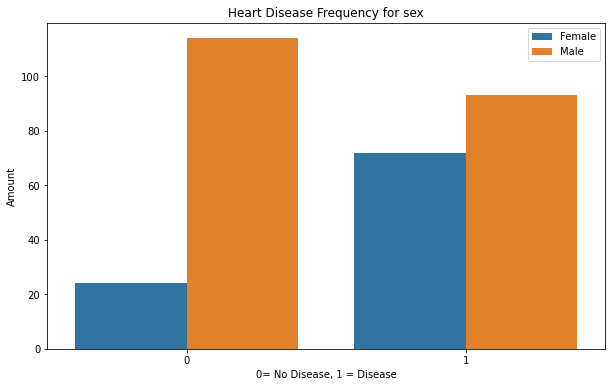

In [16]:
plt.figure(figsize=(10,6));
sns.countplot(x='target', hue='sex',data=df);
plt.title("Heart Disease Frequency for sex");
plt.xlabel("0= No Disease, 1 = Disease");
plt.ylabel("Amount");
plt.legend(["Female","Male"]);
#plt.xticks(rotation=0);


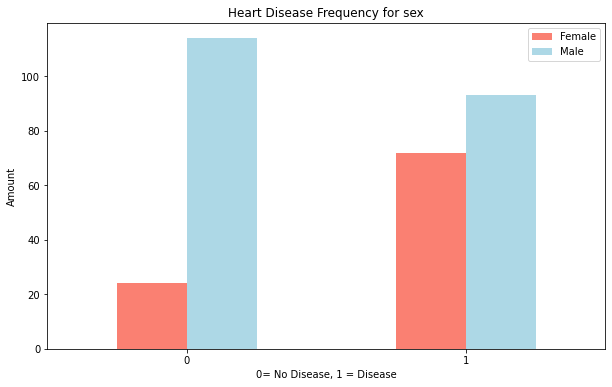

In [17]:
# create a plot of crosstab
pd.crosstab(df.target,df.sex).plot(kind='bar',figsize=(10,6),color=['salmon','lightblue'])
plt.title("Heart Disease Frequency for sex");
plt.xlabel("0= No Disease, 1 = Disease");
plt.ylabel("Amount");
plt.legend(["Female","Male"]);
plt.xticks(rotation=0);

The chart shows that males make up a much larger portion of the dataset, especially among those without heart disease. While males still have slightly higher 
counts among those with the disease, females show a noticeable increase compared to their no-disease group. Overall, this suggests that sex is related 
to heart disease distribution, with males being more prevalent overall but females having a relatively higher proportion of disease.

## Age vs. Max Heart Rate for Heart Disease

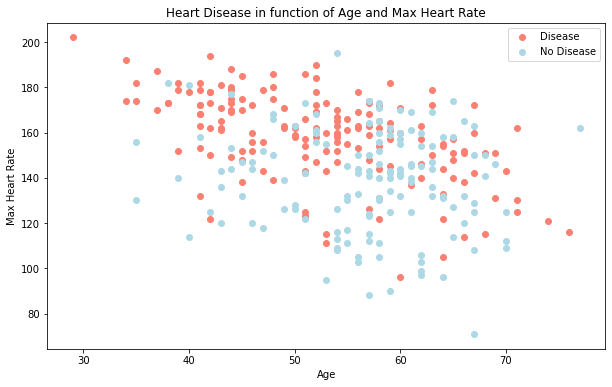

In [18]:
# create another figure 
plt.figure(figsize=(10,6));

# scatter with positive examples 
plt.scatter(df.age[df['target']==1],
            df.thalach[df.target==1],
            c='salmon');


# scatter with negative examples 
plt.scatter(df.age[df['target']==0],
            df.thalach[df.target==0],
            c='lightblue');


# Add some helpful info
plt.title('Heart Disease in function of Age and Max Heart Rate')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.legend(['Disease','No Disease']);

This scatter plot shows the relationship between age and maximum heart rate, colored by heart disease status. Overall, there is a negative trend as 
age increases maximum heart rate tends to decrease. Individuals with heart disease (red) are more concentrated at lower max heart rates, while those without disease (blue) are more common at higher heart rates, though there is considerable overlap. This suggests that lower maximum heart rate and increasing age are associated with a higher likelihood of heart disease, but neither feature alone clearly separates the two groups.


<Figure size 1080x504 with 0 Axes>

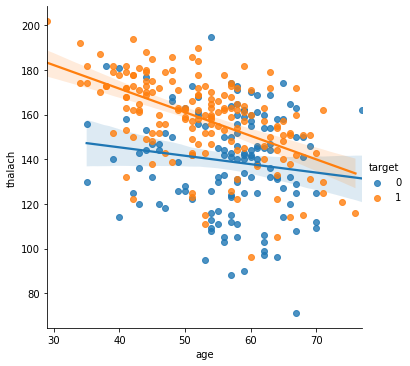

In [19]:
plt.figure(figsize=(15,7));
sns.lmplot(x='age',y='thalach',data=df,hue='target');

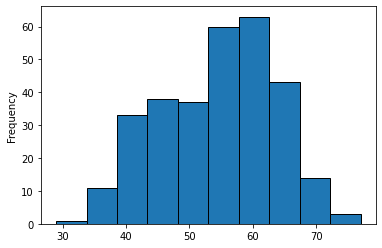

In [20]:
# check the distribution of the age column with histogram 
df.age.plot.hist(ec='black');

### Heart Disease Frequency per Chest Pain Type

cp - chest pain type
* 0: Typical angina: chest pain related decrease blood supply to the heart
* 1: Atypical angina: chest pain not related to heart
* 2: Non-anginal pain: typically esophageal spasms (non heart related)
* 3: Asymptomatic: chest pain not showing signs of disease


In [21]:
pd.crosstab(df.cp,df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


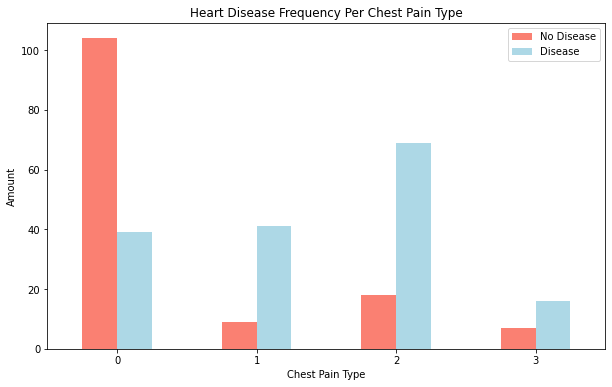

In [22]:
# Make the crosstab more visual 
pd.crosstab(df.cp, df.target).plot(kind='bar',
                                  figsize=(10,6),
                                  color=['salmon','lightblue']);

# Add some communication 
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel('Chest Pain Type')
plt.ylabel('Amount')
plt.legend(['No Disease', 'Disease']);
plt.xticks(rotation=0);

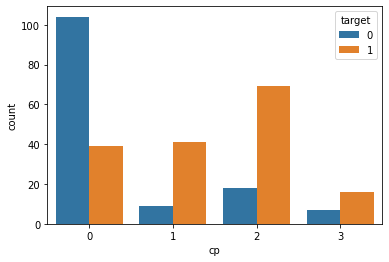

In [23]:
sns.countplot(x='cp',hue='target',data=df);

In [24]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [25]:
# Make a correlation matrix 
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


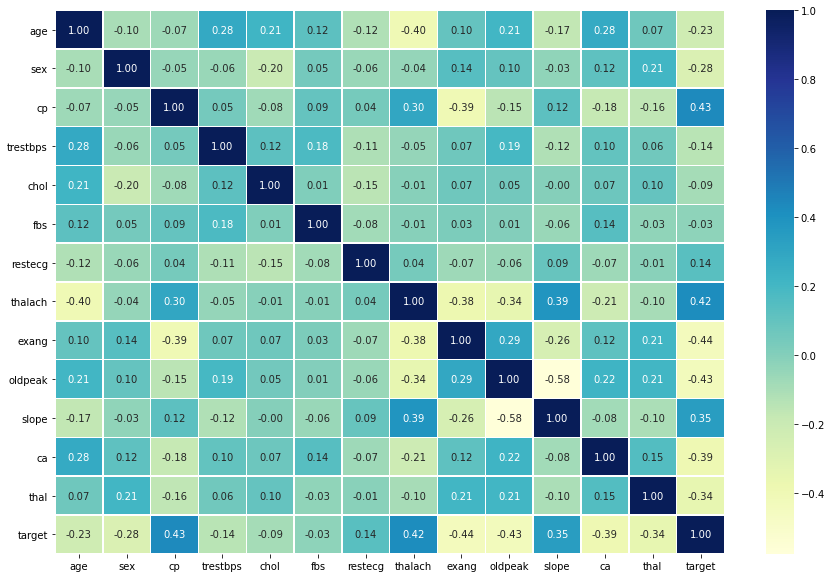

In [27]:
# Let's make our correlation matrix a little prettier
corr_matrix = df.corr();
fig , ax = plt.subplots(figsize=(15,10));
ax = sns.heatmap(corr_matrix , annot=True, linewidths=0.5, fmt='.2f',cmap='YlGnBu');

## 5. Modelling 

In [28]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [29]:
# Split data into X and Y 
x = df.drop('target',axis=1)
y = df['target']

In [30]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [31]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [87]:
# split data into train and test sets 
np.random.seed(42)
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)



In [88]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [89]:
y_train 

132    1
202    0
196    0
75     1
176    0
      ..
188    0
71     1
106    1
270    0
102    1
Name: target, Length: 242, dtype: int64

Now we've got our data splits into training and test sets, it's time to build machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set. 

We're going to try 3 different machine learning models:
1. Logistic Regression
2. K-Nearest Neighbours Classifiers 
3. Random Forest Classifier

In [90]:
# Put models in a dictionary  
models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

# create a function to fit and score models 
def fit_and_score(models, x_train,x_test,y_train,y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different scikit-Learn machine learning models 
    x_train : training data (no labels)
    x_test : testing data (no labels)
    y_train :  training labels 
    y_test : test labels 
    """
    # set random seed 
    np.random.seed(42)
    # Make a dictionary to keep model scores 
    model_scores = {}
    # Loop through models 
    for name, model in models.items():
        # Fit the model to the data 
        model.fit(x_train,y_train)
        # Evaluate the model and apppend its score to model_scores
        model_scores[name] = model.score(x_test,y_test)
    return model_scores

In [91]:
model_scores = fit_and_score(models=models, x_train=x_train,x_test=x_test,y_train=y_train,y_test=y_test)
model_scores

C:\Users\hi\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8852459016393442,
 'KNN': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

## Model Comparison

<AxesSubplot:>

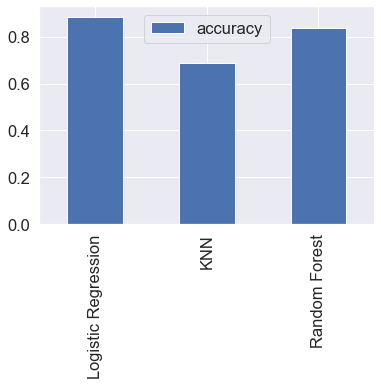

In [92]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar()

Now we've got a baseline model...and we know a model's first predictions aren't always what we should based our next steps off. What should we do?

Let's look at the following: 
* Hypyterparameter tuning 
* Feature importance 
* Confusion matrix 
* cross-validation
* Precision 
* Recall 
* F1 score 
* Classification report 
* ROC curve 
* Area under the curve (AUC)



## Hyperparameter tuning with RandomizedSearchCV

We're going to tune: 
* LogisticRegression()
* RandomForestClassifier()

... using RandomizedSearchCV 

In [97]:
# Create a hyperparameter grid for LogisticRegression 
log_reg_grid = {"C": np.logspace(-4, 4, 20),"solver": ["liblinear"]}

# Create a hyperparameter grid for RandomForestClassifier 
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10], 
           "min_samples_split": np.arange(2,20,2),
           "min_samples_leaf": np.arange(1, 20, 2)}

Now we've got hyperparameter grids setup for each of our models, 
let's tune them using RandomizedSearchCV...

In [98]:
# Tune LogisticRegression 

np.random.seed(42)

# Setup random hyperparametr search for logisticRegression 
rs_log_reg = RandomizedSearchCV (estimator = LogisticRegression(),
                                 param_distributions=log_reg_grid,
                                 cv=5,
                                 n_iter=20,
                                 verbose=True)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(x_train,y_train) 

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.6s finished


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [99]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 0.23357214690901212}

In [100]:
rs_log_reg.score(x_test,y_test)

0.8852459016393442

Now we've tuned LogisticRegression(), let's do the same for RandomForestClassifier()...

In [101]:
# Setup random seed 
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier 
rs_rf = RandomizedSearchCV(estimator = RandomForestClassifier(),param_distributions = rf_grid,
                           n_iter=30,
                           cv=5,
                          verbose=True)


# Fit random hyperparameters search model for RandomForestClassifier()
rs_rf.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 150 out of 150 | elapsed:  2.7min finished


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=30,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [102]:
rs_rf.best_params_

{'n_estimators': 260,
 'min_samples_split': 16,
 'min_samples_leaf': 17,
 'max_depth': 3}

In [103]:
rs_rf.score(x_test,y_test)

0.8688524590163934

## Hyperparameter Tuning with GridSearchCV

since our LogisticRegression model provides the best scores so far, 
we'll try and improve hem agian using GridSearchCV...

In [104]:
# Different hyperparameters for our LogisticRegression model 
log_reg_grid = {"C": np.logspace(-4,4,30),
                "solver": ["liblinear"]}


# Setup grid hyperparameter search for LogisticRegression 
gs_log_reg = GridSearchCV(LogisticRegression(),param_grid=log_reg_grid,cv=5,verbose=True)


# Fit grid hyperparameter search model 
gs_log_reg.fit(x_train,y_train);


Fitting 5 folds for each of 30 candidates, totalling 150 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 150 out of 150 | elapsed:    1.0s finished


In [105]:
#check the best hyperparameters 
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [106]:
# Evaluate the grid search LogisticRegression model 
gs_log_reg.score(x_test,y_test)

0.8852459016393442

## Evaluating our tuned machine learning classifier, beyond accuracy 

* ROC curve and AUC score 
* Confusion matrix 
* Classification report 
* Precision 
* Recall 
* F1-score 

... and it would be great if cross-validation was used where possible 

To make comparisons and evaluate our trained model, first we need to make predictions. 

In [107]:
# Make predictions with tuned model 
y_preds = gs_log_reg.predict(x_test)

In [108]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [109]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

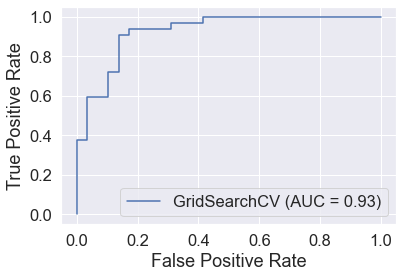

In [110]:
# Plot ROC curve and calculate AUC metric 
plot_roc_curve(gs_log_reg, x_test, y_test);

In [111]:
# confusion matrix 
print(confusion_matrix(y_test,y_preds)) 

[[25  4]
 [ 3 29]]


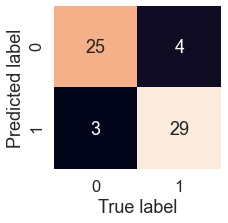

In [112]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    plots a nice looking confusuon matrix using Seaborn's heatmap()
    """
    fig,ax  = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test,y_preds),
                                      annot=True,
                                      cbar=False)
    
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    
    
    
plot_conf_mat(y_test,y_preds)
    

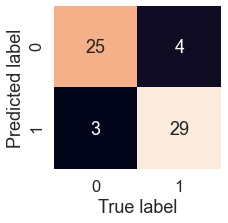

In [113]:
plt.figure(figsize=(3,3))

sns.heatmap(confusion_matrix(y_test,y_preds),annot=True,cbar=False)
plt.xlabel("True label");
plt.ylabel("Predicted label");

Now we've got a ROC curve, an AUC metric and a confusion matrix, let's get a classification report as well as cross-validated precision, recall and f1-score.

In [114]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### Calculate evaluation metrics using cross-validation 

We're going to calculate accuracy, precision, recall and f1-score of our model 
using cross-validation and to do so we'll be using `cross_val_score()`.

In [115]:
# Check best hyperparameters 
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [117]:
# Create a new classifier with best parameters 
clf = LogisticRegression(C=0.20433597178569418,solver='liblinear')

In [118]:
# Cross-validated accuracy 

cv_acc = cross_val_score(clf,
                        x,
                        y,
                        cv=5,
                        scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.86885246, 0.88333333, 0.75      ])

In [123]:
cv_acc = np.mean(cv_acc)
cv_acc

0.8446994535519124

In [120]:
# Cross-validated precision  

cv_precision = cross_val_score(clf,
                        x,
                        y,
                        cv=5,
                        scoring="precision")
cv_precision

array([0.775     , 0.88571429, 0.85714286, 0.86111111, 0.725     ])

In [125]:
cv_precision = np.mean(cv_precision)
cv_precision

0.8207936507936507

In [126]:
# Cross-validated recall  

cv_recall = cross_val_score(clf,
                        x,
                        y,
                        cv=5,
                        scoring="recall")
cv_recall

array([0.93939394, 0.93939394, 0.90909091, 0.93939394, 0.87878788])

In [128]:
cv_recall = np.mean(cv_recall)
cv_recall

0.9212121212121213

In [129]:
# Cross-validated f1-score  
cv_f1 = cross_val_score(clf,
                        x,
                        y,
                        cv=5,
                        scoring="f1")
cv_f1

array([0.84931507, 0.91176471, 0.88235294, 0.89855072, 0.79452055])

In [131]:
cv_f1 = np.mean(cv_f1)
cv_f1

0.8673007976269721

<AxesSubplot:title={'center':'Cross-validated classification metrics'}>

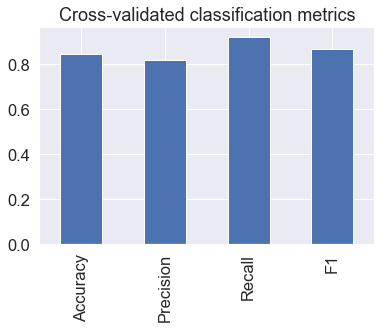

In [137]:
# Visualize cross-validated metrics 
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                           "Precision": cv_precision,
                           "Recall": cv_recall,
                           "F1": cv_f1},
                           index=[0]
                            ) 



cv_metrics.T.plot.bar(title="Cross-validated classification metrics",legend=False)

### Feature Importance 

Feature importance is another as asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each machine learning model. One way to find feature importance is to search for "(MODEL NAME) feature importance" 

Let's find the feature importance for our LogisticRegression model... 

In [141]:
# Fit an instance of LogisticRegression
#gs_log_reg.best_params_
clf = LogisticRegression(C=0.20433597178569418,
                         solver = 'liblinear')

clf.fit(x_train,y_train)

LogisticRegression(C=0.20433597178569418, solver='liblinear')

In [142]:
# Check coef_
clf.coef_

array([[ 0.00316728, -0.86044651,  0.66067041, -0.01156993, -0.00166374,
         0.04386107,  0.31275847,  0.02459361, -0.6041308 , -0.56862804,
         0.45051628, -0.63609897, -0.67663373]])

In [156]:
# Match coef's of features to columns 
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'age': 0.0031672801993431563,
 'sex': -0.8604465072345515,
 'cp': 0.6606704082033799,
 'trestbps': -0.01156993168080875,
 'chol': -0.001663744504776871,
 'fbs': 0.043861071652469864,
 'restecg': 0.31275846822418324,
 'thalach': 0.024593613737779126,
 'exang': -0.6041308000615746,
 'oldpeak': -0.5686280368396555,
 'slope': 0.4505162797258308,
 'ca': -0.6360989676086223,
 'thal': -0.6766337263029825}

<AxesSubplot:title={'center':'Feature Importance'}>

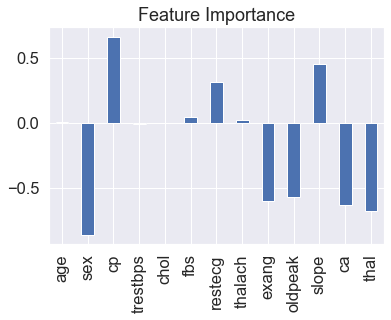

In [158]:
# Visualize feature importance 
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title="Feature Importance",legend=False)

In [159]:
pd.crosstab(df['sex'],df['target'])

target,0,1
sex,,
0,24,72
1,114,93


In [160]:
pd.crosstab(df['slope'],df['target'])

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


slope - the slope of the peak exercise ST segment
* 0: Upsloping: better heart rate with excercise (uncommon)
* 1: Flatsloping: minimal change (typical healthy heart)
* 2: Downslopins: signs of unhealthy heart

## Feature Importance Interpretation

The feature importance analysis highlights the variables that contribute most to predicting heart disease.

Most Influential Features:

- Sex: Gender plays a major role, with males showing a higher likelihood of heart disease.
- Age: Older age increases the likelihood of developing heart disease, a well-known factor in cardiovascular health.
- Chest Pain Type (cp): Chest pain is a critical indicator of heart disease. Typical angina, related to heart issues, is strongly predictive.
- Maximum Heart Rate Achieved (thalach): A higher maximum heart rate achieved during exercise is typically associated with better cardiovascular health, while lower rates indicate potential heart issues.
- Resting Electrocardiographic Results (restecg): Abnormal resting electrocardiographic results (e.g., ST-T wave abnormalities) are significant in identifying heart disease.
- Number of Major Vessels (ca): The number of colored vessels detected by fluoroscopy indicates blood flow and is a strong predictor of heart disease. More vessels with poor blood flow (blockages) increase the risk.
- Exercise-Induced Angina (exang): The presence of chest pain during exercise is indicative of stress on the heart, making it a strong predictor of heart disease.
- Slope of the Peak Exercise ST Segment (slope): The slope of the peak exercise ST segment provides insight into how the heart responds to stress, with more abnormal slopes correlating with higher risk.
- ST Depression (oldpeak): ST depression during exercise relative to rest reflects stress on the heart. Negative importance suggests it's less influential than other features.

These clinical indicators are commonly used by healthcare professionals when evaluating cardiovascular health and diagnosing heart disease. The model confirms that these features play a critical role in predicting patient outcomes.

### Key Insights:
- The most influential features align closely with clinical knowledge used by healthcare professionals when diagnosing heart disease, including age, sex, chest pain type, and heart rate.
- Resting electrocardiographic results and the number of vessels with poor blood flow are also highly predictive of heart disease, confirming their clinical relevance in cardiovascular diagnosis.

## Model Strengths:
- The model successfully identifies key cardiovascular risk factors, such as age, sex, and chest pain type, which are commonly used in clinical assessments.
- Features like maximum heart rate and resting electrocardiographic results align with established clinical practices, enhancing the model's reliability.

## Model Limitations

While the models demonstrate strong predictive performance, several limitations should be considered:

- The dataset size is relatively small and may not represent the broader population.
- Important risk factors such as lifestyle habits, genetics, and diet are not included.
- Machine learning predictions should not be used as a medical diagnosis without clinical validation.

Future work could explore larger datasets and more advanced machine learning models to improve prediction accuracy.

# Conclusion

This project explored the use of machine learning techniques to predict heart disease using clinical patient data.

Exploratory data analysis revealed strong relationships between features such as chest pain type, age, maximum heart rate, and heart disease diagnosis.

Multiple machine learning models were trained and evaluated, including Logistic Regression, KNN, and Random Forest. Among these, Random Forest demonstrated the strongest predictive performance.

Feature importance analysis highlighted key medical indicators associated with cardiovascular risk, reinforcing the importance of clinical variables used in real-world diagnosis.

This project demonstrates how machine learning can support healthcare analytics by identifying patterns in patient data and assisting in early detection of heart disease risk.